Kalkidan Tadese

1. What predictors should be considered continuous or categorical data? why?

season, mnth, day, hr, holiday, weekday, workingday, and weathersit are categorical variables, because they represent distinct groups or categories, some of which have an order (mnth, day - ordinal variables). Temp, atemp, hum, windspeed are continuous variables as they represent measurable quantities that can take on a range of values. Casual and registered bikers are discrete variables that will be treated as continuous in modeling because they can take on a wide range of values.

2. For each predictor, fit a simple linear regression model to predict the response (casual and registered bikers separately). Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

In [1]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset and drop bikers column
bikeshare = pd.read_csv("Bikeshare.csv")
bikeshare.drop(columns=["bikers"], inplace=True)
#remove rows with missing values
bikeshare.dropna(inplace=True)
bikeshare.head()

,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0,3,13
1,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0,8,32
2,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0,5,27
3,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0,3,10
4,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0,0,1


In [2]:
#subset the dataframe to convert categorical text columns to numerical dummy vars
#one-hot encoding creates binary columns for each category in each column
bikeshare_encoded = pd.get_dummies(bikeshare, columns=['mnth', 'weathersit'], drop_first=True)
#drop_first=True in pandas drops one redundant column e.g., keeps only Feb-Dec to avoid multicollinearity
bikeshare_encoded

,season,day,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,...,mnth_July,mnth_June,mnth_March,mnth_May,mnth_Nov,mnth_Oct,mnth_Sept,weathersit_cloudy/misty,weathersit_heavy rain/snow,weathersit_light rain/snow
0,1,1,0,0,6,0,0.24,0.2879,0.81,0.0000,...,False,False,False,False,False,False,False,False,False,False
1,1,1,1,0,6,0,0.22,0.2727,0.80,0.0000,...,False,False,False,False,False,False,False,False,False,False
2,1,1,2,0,6,0,0.22,0.2727,0.80,0.0000,...,False,False,False,False,False,False,False,False,False,False
3,1,1,3,0,6,0,0.24,0.2879,0.75,0.0000,...,False,False,False,False,False,False,False,False,False,False
4,1,1,4,0,6,0,0.24,0.2879,0.75,0.0000,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,1,365,19,0,6,0,0.42,0.4242,0.54,0.2239,...,False,False,False,False,False,False,False,False,False,False
8641,1,365,20,0,6,0,0.42,0.4242,0.54,0.2239,...,False,False,False,False,False,False,False,False,False,False
8642,1,365,21,0,6,0,0.40,0.4091,0.58,0.1940,...,False,False,False,False,False,False,False,False,False,False
8643,1,365,22,0,6,0,0.38,0.3939,0.62,0.1343,...,False,False,False,False,False,False,False,False,False,False


In [3]:
bikeshare.columns

Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

In [4]:
#part 1 = predicting response of casual bikers

# for loop to keep all columns except response variables
features = [col for col in bikeshare_encoded.columns if col not in ["casual", "registered"]]
bikertypes = bikeshare_encoded[["casual", "registered"]]

# Initialize a dictionary to store results
single_coeffs = {}

# Convert True/False dummy variables to 1/0 for modeling
bikeshare_encoded_2 = bikeshare_encoded.copy()
bikeshare_encoded_2.replace({False:0, True:1}, inplace = True)

# bikertypes.items() returns an iterable of (column_name, column_data) pairs for the DataFrame bikertypes
# b will be the column name (e.g., "casual" or "registered").
# bikey will be the column data as a pandas Series.
for b, bikey in bikertypes.items(): #loop over biker type; b - casual or registered; bikey is data
    single_coeffs[b] = {}  # Initialize a dictionary for each biker type
    for i in features: #loop over predictors
        #prepend = false, means that column will be added to end of the dataframe, instead of the beginning
        #add_constant adds a constant to X (intercept term)
        bikeshareX = sm.add_constant(bikeshare_encoded_2[[i]], prepend=False)
        mod = sm.OLS(bikey, bikeshareX) #creating the lr model
        res = mod.fit() #fitting the model
        print(f"Predicting response for {b} and {i} feature\n")
        print(res.summary()) #print summary report
          # Save the coefficient, CI, and p-value
        single_coeffs[b][i] = {
            "coefficient": res.params[i],  # Coefficient of the predictor-response relationship
            "p_value": res.pvalues[i],  
            "confidence_interval": res.conf_int().loc[i].tolist()}

/tmp/ipykernel_67271/2646069010.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bikeshare_encoded_2.replace({False:0, True:1}, inplace = True)


Predicting response for casual and season feature

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     177.6
Date:                Wed, 14 May 2025   Prob (F-statistic):           4.04e-40
Time:                        20:10:59   Log-Likelihood:                -43814.
No. Observations:                8645   AIC:                         8.763e+04
Df Residuals:                    8643   BIC:                         8.765e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
s

In [5]:
single_coeffs #nested dictionaries for univariate linear regression values
# { response_name: { predictor_name: {'coefficient': ..., 'p_value': ...}, … }, … }

{'casual': {'season': {'coefficient': 4.985437532672498,
   'p_value': 4.037224250029025e-40,
   'confidence_interval': [4.2521093756404404, 5.718765689704556]},
  'day': {'coefficient': 0.03371193827822942,
   'p_value': 2.336838146393788e-17,
   'confidence_interval': [0.02593154134304071, 0.041492335213418136]},
  'hr': {'coefficient': 1.70773690291504,
   'p_value': 6.454284610276839e-184,
   'confidence_interval': [1.594781335110978, 1.820692470719102]},
  'holiday': {'coefficient': 12.53250666738343,
   'p_value': 8.573364718823195e-07,
   'confidence_interval': [7.544784211152303, 17.520229123614556]},
  'weekday': {'coefficient': -0.26086064529476194,
   'p_value': 0.21028982375376246,
   'confidence_interval': [-0.6690054162058057, 0.14728412561628185]},
  'workingday': {'coefficient': -27.123636180025567,
   'p_value': 1.7949470563359051e-211,
   'confidence_interval': [-28.78924892289026, -25.458023437160875]},
  'temp': {'coefficient': 93.97658323850136,
   'p_value': 0.0,


In [14]:
#determining which variables are significant; which aren't significant
sig_res = [] #initialize list to store sig results
not_sig_res = [] # init list to store non-sig results
for b in single_coeffs: # loop over each response (casual, registered)
    for i in single_coeffs[b]: #loop over each predictor for that response
        if single_coeffs[b][i]['p_value'] < 0.05: # filter for pvalue < 0.05
            sig_res.append({ #add info to list as a dictionary if predictor pval is below 0.05
                'response': b, #response variable
                'predictor': i, #predictor
                'coef': single_coeffs[b][i]['coefficient'], # response-predictor relationship coef
                'p_value': single_coeffs[b][i]['p_value']}) # response-predictor relationship sign.
        else: #if pvalue > 0.05, record only the response and predictor
            not_sig_res.append({
            'response': b,
            'predictor': i})

#convert list of dictionaries into dataframe to visualize
sig_df = pd.DataFrame(sig_res)
sig_df #display df of significant predictors
not_sig_df = pd.DataFrame(not_sig_res)
not_sig_df #display df of non-significant preds

,response,predictor
0,casual,weekday
1,casual,weathersit_heavy rain/snow
2,registered,weekday
3,registered,mnth_Nov
4,registered,weathersit_heavy rain/snow


Describe the results:

Atemp (temperature that it feels like) and temp showed strong positive relationships with casual and registered riders; as  temperatures rise, rider counts for both types of bikers  increase. Humidity showed a strong negative correlation for casual and registered riders; higher humidity corresponded to fewer bikers for both biker types. Registered riders showed a slightly positive relationship with workingday, whereas causal riders had a slightly negative relationship, riding less on workdays. No clear correlation between weekday and either casual or registered riders; trend line remained flat, though casual riders had half the rider count compared to registered riders. Registered riders showed a negative relationship to holidays, while casual riders showed a positive relationship. Both rider types showed positive relationships with hour of the day and slightly positive relationships with season. Casual riders displayed a parabolic trend across months, with higher rider counts during summer months and lower counts at the start and end of the year; registered riders showed a similar but less pronounced seasonal pattern. Both rider types showed a slightly positive relationship with windspeed; registered bikers demonstrating a stronger positive trend than casual bikers; both rider types showed similar riding count patterns across weather situations, with worse weather conditions (heavy rain or snow) corresponding to lower rider counts and clearer weather associated with increased ridership. Its interesting that from the simple linear regression model, comparing one predictor at each time against each response, the results demonstrate that the relationship had a p-value below 0.05 for most predictors, except for weekday. For a given predictor, it had a p <0.05 for at least one of the two simple linear regression models performed.

In [7]:
bikeshare.dtypes

season          int64
mnth           object
day             int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit     object
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
dtype: object

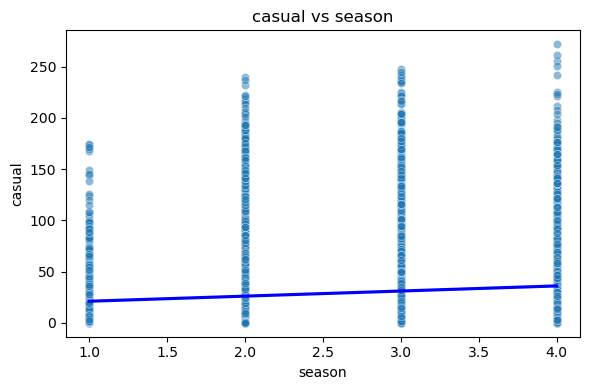

/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


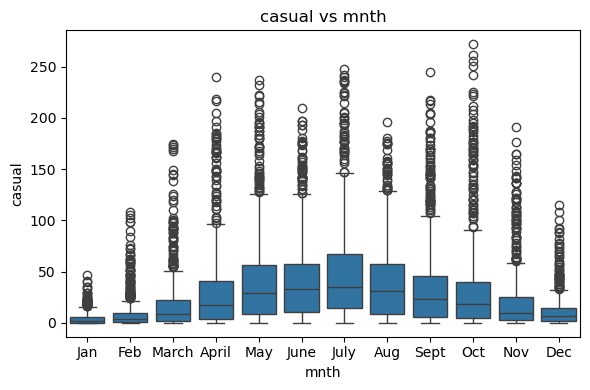

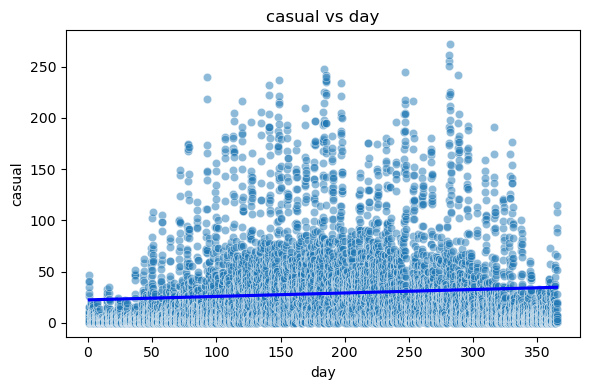

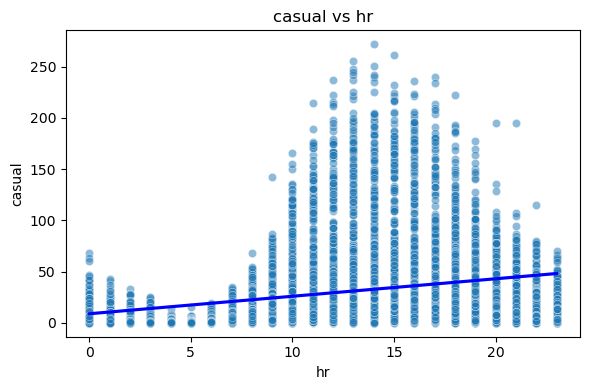

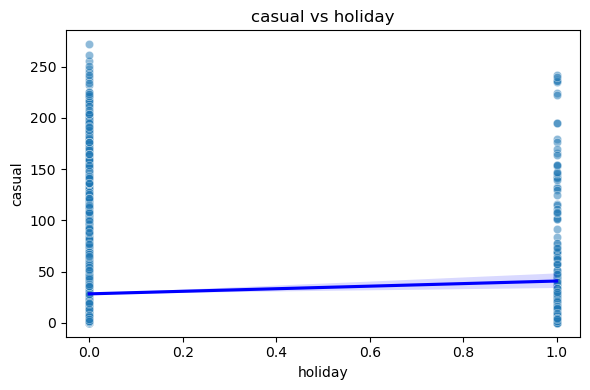

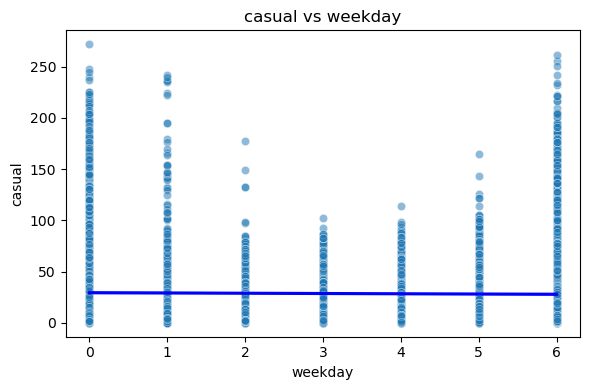

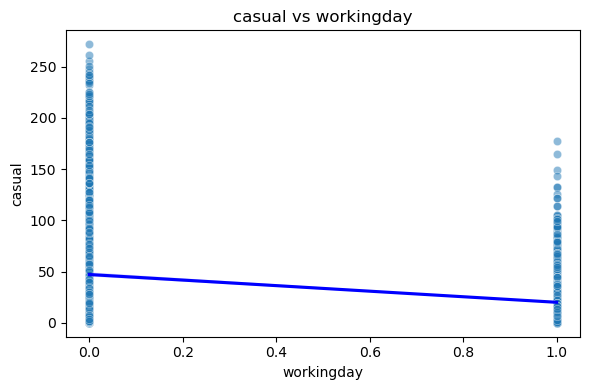

/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


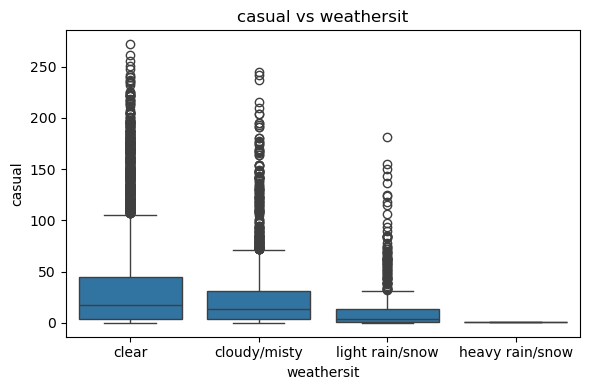

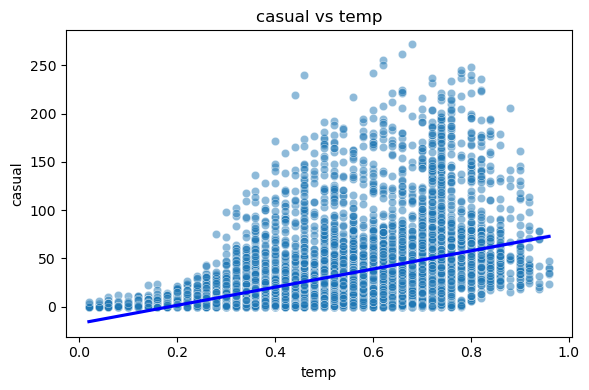

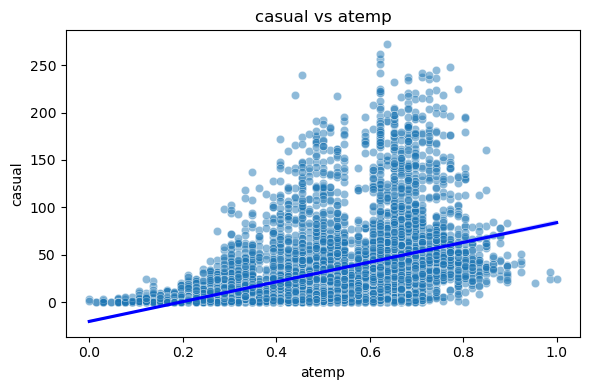

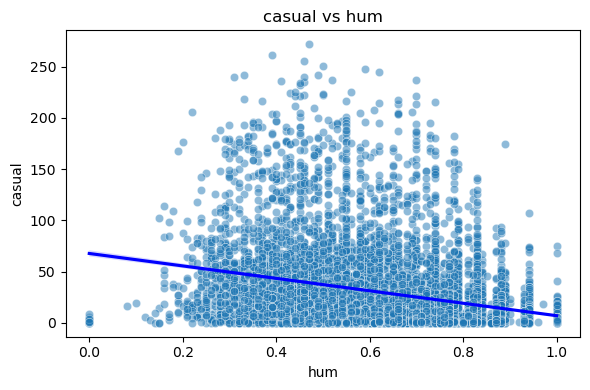

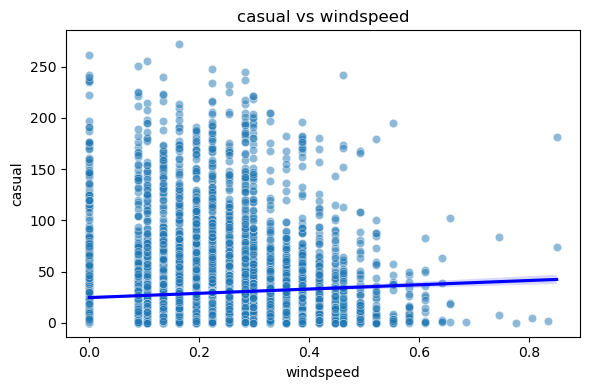

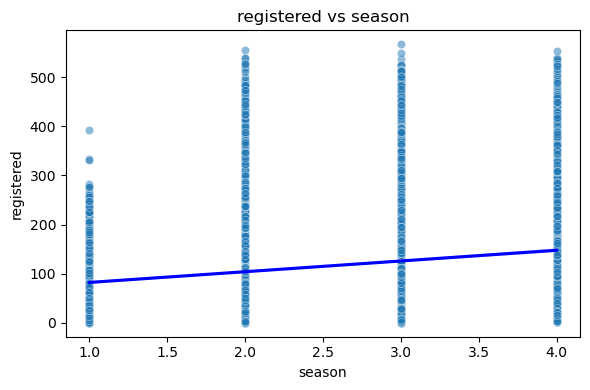

/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


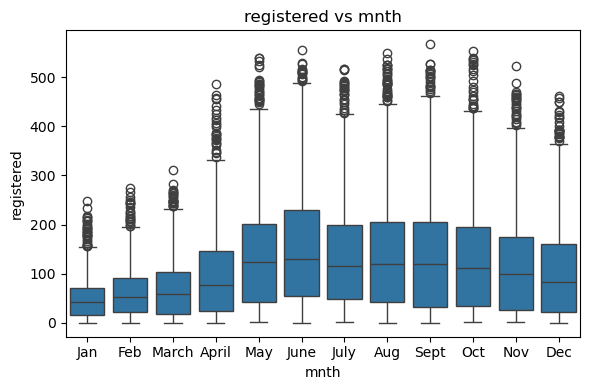

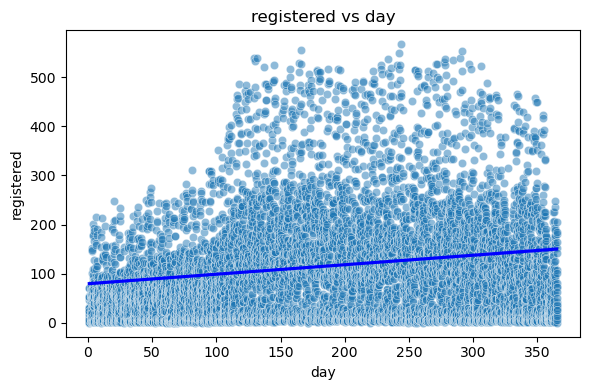

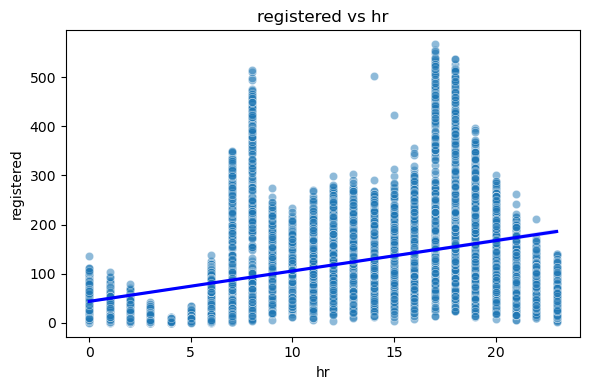

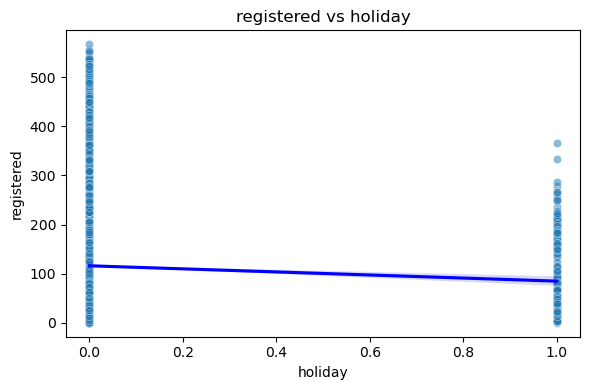

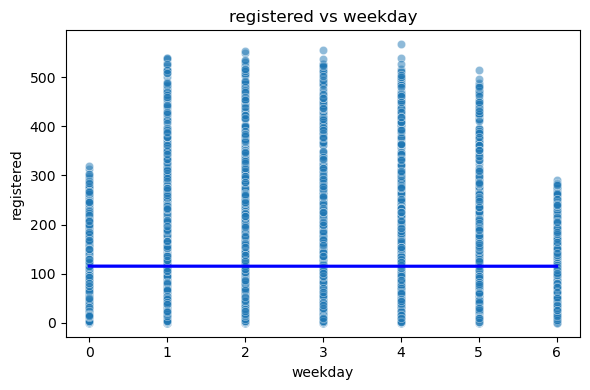

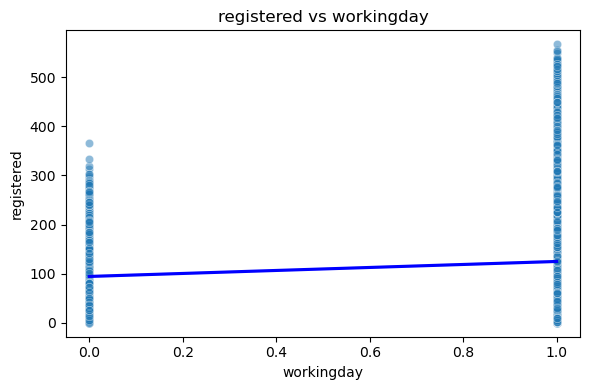

/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


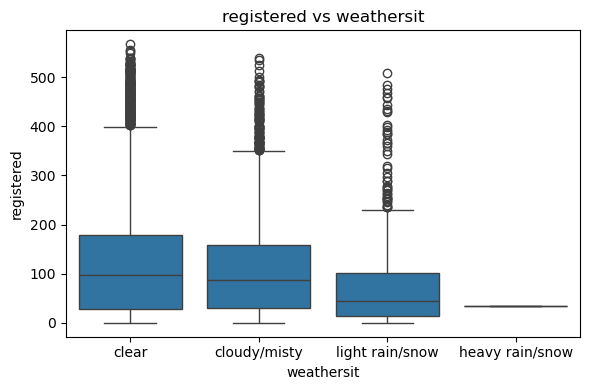

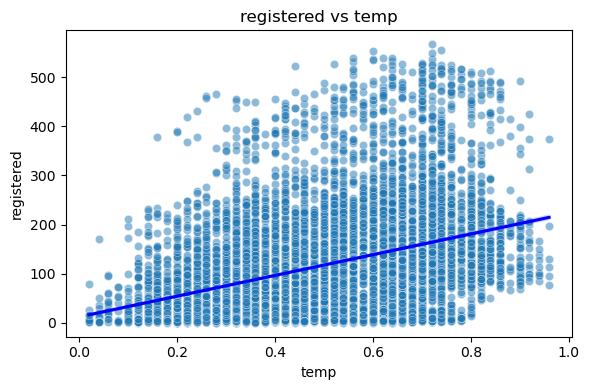

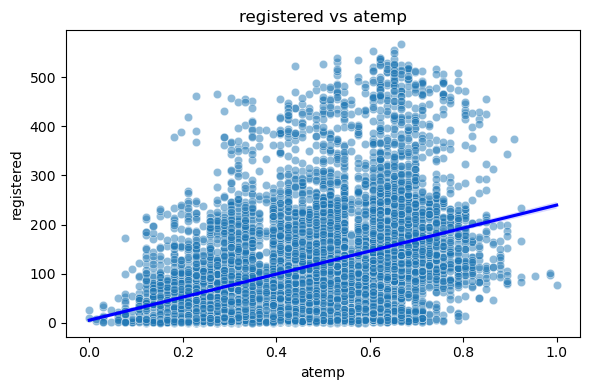

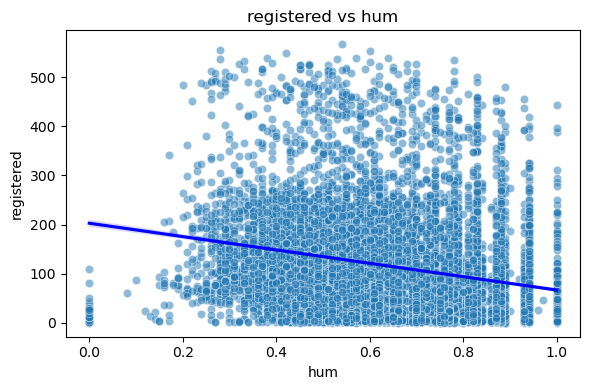

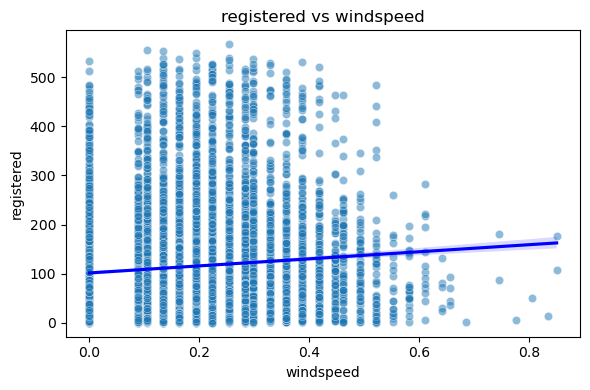

In [8]:
# Step 2: Visualize the relationship between features and bikertypes

# Define the predictor features by excluding the response variables 'casual' and 'registered'
features = [col for col in bikeshare.columns if col not in ["casual", "registered"]]

# Iterate over the two biker types (casual and registered)
# - b is the column name as a string ('casual' or 'registered')
# - bikey is the corresponding Pandas Series containing the data for that column
for b, bikey in bikertypes.items(): #loop over biker type
   for i in features: # Loop over each predictor feature to visualize its relationship with the current biker type     
        if i not in bikeshare.columns: # Skip feature if it is not present in the bikeshare
            break
        plt.figure(figsize=(6, 4)) # Initialize a new figure for plotting
        if bikeshare[i].dtype == 'object': # Select plot type based on feature data type
            sns.boxplot(x=i, y=bikey, data=bikeshare) #boxplot for categorical
        else: #if feature not categorical, use scatterplot
            sns.scatterplot(x=i, y=bikey, data=bikeshare, alpha=0.5) #scatterplot for numeric
            sns.regplot(x=i, y=bikey, data=bikeshare, scatter=False, color='blue') #overlay regression line for trends
        plt.title(f'{b} vs {i}')
        plt.tight_layout() #formatting
        plt.show() #display

3. Fit a multiple regression model to predict the response (casual and registered bikers
separately) using all of the predictors. For which predictors can
we reject the null hypothesis 𝐻0 ∶ 𝛽𝑗 = 0?

In [9]:
#multiple regression model -- with both casual and registered
features = [col for col in bikeshare_encoded.columns if col not in ["casual", "registered"]]
bikertypes = bikeshare_encoded[["casual", "registered"]]
multiple_coeffs = {}
multiple_pvals = {}
# bikertypes.items() returns an iterable of (column_name, column_data) pairs for the DataFrame bikertypes.
# b will be the column name (e.g., "casual" or "registered").
# bikey will be the column data as a pandas Series.
for b, bikey in bikertypes.items(): #loop over biker type
    #prepend = false, means that column will be added to end of the dataframe, instead of the beginning
    #add_constant adds a constant to X (intercept term)
    bikeshareX = sm.add_constant(bikeshare_encoded_2[features], prepend=False)
    mod = sm.OLS(bikey, bikeshareX)
    #fitting the model
    res = mod.fit()
    multiple_coeffs[b] = res.params.drop("const")  # Exclude the intercept
    multiple_pvals[b] = res.pvalues.drop("const") #storing p-values
    #print summary report
    print(f"Predicting response for {b} using all features\n")
    print(res.summary())



Predicting response for casual using all features

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     348.2
Date:                Wed, 14 May 2025   Prob (F-statistic):               0.00
Time:                        20:11:43   Log-Likelihood:                -40973.
No. Observations:                8645   AIC:                         8.200e+04
Df Residuals:                    8620   BIC:                         8.217e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

In [10]:
multiple_pvals

{'casual': season                         8.518140e-02
 day                            3.083833e-04
 hr                             1.523096e-91
 holiday                        1.923060e-06
 weekday                        7.017044e-01
 workingday                     0.000000e+00
 temp                           2.567596e-17
 atemp                          8.984893e-01
 hum                           1.661929e-153
 windspeed                      8.817105e-04
 mnth_Aug                       2.161991e-01
 mnth_Dec                       3.256165e-03
 mnth_Feb                       1.151161e-05
 mnth_Jan                       1.091911e-03
 mnth_July                      2.030159e-03
 mnth_June                      7.889216e-05
 mnth_March                     5.190188e-02
 mnth_May                       2.343692e-02
 mnth_Nov                       2.416144e-03
 mnth_Oct                       2.163537e-04
 mnth_Sept                      1.802923e-02
 weathersit_cloudy/misty        2.877087e-01


In [11]:
# determining significance of association using all predictors
# filter for preds with p-val < 0.05

Multi_sig_res = []
Multi_not_sig_res = []
for b in multiple_pvals:
    for i, p_val in multiple_pvals[b].items():
        coef = multiple_coeffs[b][i]
        if p_val < 0.05:
            Multi_sig_res.append({
                'response': b,
                'predictor': i,
                'coefficient': coef,
                'p_value': p_val })
        else:
            Multi_not_sig_res.append({
            'response': b,
            'predictor': i,
            'coefficient': coef,
            'p_value': p_val })
    
Multi_sig_df = pd.DataFrame(Multi_sig_res)
Multi_not_sig_df = pd.DataFrame(Multi_not_sig_res)
Multi_not_sig_df
Multi_sig_df

,response,predictor,coefficient,p_value
0,casual,day,-0.123595,3.083833e-04
1,casual,hr,0.948534,1.523096e-91
2,casual,holiday,-9.088886,1.923060e-06
3,casual,workingday,-29.515712,0.000000e+00
4,casual,temp,119.311787,2.567596e-17
5,casual,hum,-52.937374,1.661929e-153
6,casual,windspeed,-9.204295,8.817105e-04
7,casual,mnth_Dec,25.321292,3.256165e-03
8,casual,mnth_Feb,-11.716317,1.151161e-05
9,casual,mnth_Jan,-11.546787,1.091911e-03


Describe your results.

The p-value for each term tests the null hypothesis that the coefficient is equal to zero (meaning it would have no effect on the response). A low p-value indicates that you can reject the null hypothesis 𝐻0 ∶ 𝛽𝑗 = 0. The predictors stored in the Multi_sig_df are predictors that have a meaningful addition to the multiple regression model because the changes in the predictors' value relate to the changes in the response variable.

Atemp and temp had large positive coefficients, showing a strong positive relationship with the response variable for casual and registered bikers; whereas humidity, and weathersit_light rain/snow and weathersit_heavy rain/snow had large negative coefficients, showing a strong negative relationship with the responses for both biker types. For casual biker types, the season had a slightly positive coefficient that was meaningful to the response (p-value < 0.05) and workingday were slightly negative coefficient (p-value < 0.05). In contrast, for registered riders, the season and the workingday both had slightly positive coefficients, suggesting a positive relationship between both predictors and the response. For casual and registered biker types, the windspeed, weekday, and holiday predictors were not significant, indicating that these predictors had no meaningful predictive contribution to the model.

4. How do your results from 2 compare to your results from 3? Create a plot displaying
the univariate regression coeﬀicients from 2 on the x-axis, and the multiple regression coeﬀicients from 3 on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coeﬀicient in a simple linear regression model is shown on the x-axis, and its coeﬀicient estimate in the multiple linear regression model is shown on the y-axis. Make a panel for each response.

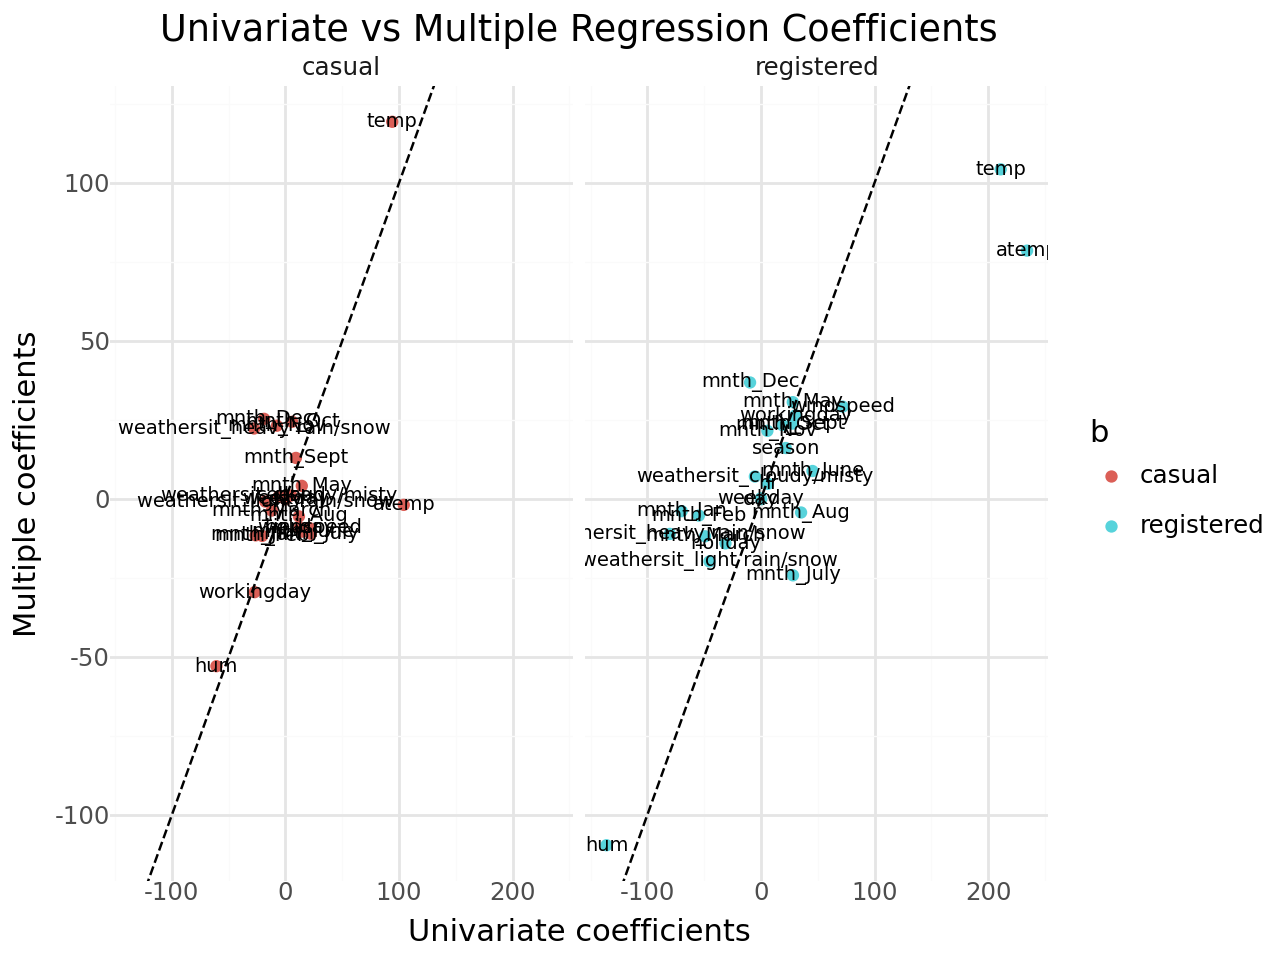

In [12]:
# Import plotnine and modules for plotting
from plotnine import (ggplot, aes, geom_text, geom_point, geom_abline, position_jitter,
facet_wrap, labs, theme_minimal)

# 1) Prepare the data
data = [] # Initialize list to store records for each predictor and biker type
for b, bikey in bikertypes.items(): # Loop over biker types (casual and registered), where:
    for i, res in single_coeffs[b].items(): # Loop over univariate regression results for current biker type
        data.append({"b": b, # Biker type (casual or registered)
                     "feature": i, # Predictor feature name
                     "uni_coef": res["coefficient"], # Coefficient from univariate model           
            "multi_coef": multiple_coeffs[b][i]})  #Coefficient from multiple regression model
# Collect univariate and multiple regression coefficients for the feature 'i'
# and store them with the corresponding biker type label 'b'

# Convert the stored records into a DataFrame for plotting
df = pd.DataFrame(data)

# 2) Plot univariate vs multiple coefficients, one panel per b
plot = (
    ggplot(df, aes(x="uni_coef", y="multi_coef", color="b"))  # Map univariate to x, multiple lr to y, color by biker type
    + geom_point(size=1.5) # Add scatter points for each feature
    + geom_abline(slope=1, intercept=0, linetype="dashed") # Add identity line (y = x) for to compare slr to mlr
    +  geom_text( # Add predictor names as labels to each point
        aes(label="feature"),
        color="black",
        size=7)
    + facet_wrap("~b") #create separate panels for each biker type
    + labs(
        title="Univariate vs Multiple Regression Coefficients",
        x="Univariate coefficients",
        y="Multiple coefficients")
    + theme_minimal() 
)
plot

In [13]:
##5. Is there evidence of non-linear association between any of the 
#predictors and the response? To answer this question, for 
#each predictor 𝑋, fit a model of the form 𝑌 = 𝛽0 + 𝛽1𝑋 + 𝛽2𝑋2 + 𝛽3𝑋3.


# for loop to keep all columns except response variables
features = [col for col in bikeshare_encoded_2.columns if col not in ["casual", "registered"]]
bikertypes = bikeshare_encoded_2[["casual", "registered"]]

# Initialize dictionary to store results for all biker types and predictors
non_linear_results = {}

# Loop over each response variable
for b, bikey in bikertypes.items(): #loop over biker type
    non_linear_results[b] = {} # Initialize sub-dictionary for the current response variable
    for feature in features:
        # Create polynomial terms (X, X^2, X^3)
        X_poly_bikeshare = pd.DataFrame({
            f"{feature}": bikeshare_encoded_2[feature],
            f"{feature}^2": bikeshare_encoded_2[feature]**2,
            f"{feature}^3": bikeshare_encoded_2[feature]**3
        })
        # Add an intercept term (constant) to the model
        X_poly = sm.add_constant(X_poly_bikeshare)  # Add intercept
        
        # Fit the model
        model = sm.OLS(bikey, X_poly).fit()
        
        # Store results
        non_linear_results[b][feature] = {
            "p_values": model.pvalues,  # P-values for terms
            "coefficients": model.params  # Coefficients
        }
        
        # Print summary (optional)
        print(f"Non-linear regression for {b} with {feature}:")
        print(model.summary())
        print("\n")

Non-linear regression for casual with season:
                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     306.9
Date:                Wed, 14 May 2025   Prob (F-statistic):          2.46e-189
Time:                        20:11:47   Log-Likelihood:                -43465.
No. Observations:                8645   AIC:                         8.694e+04
Df Residuals:                    8641   BIC:                         8.697e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

6. Describe the differences in most explanatory predictors between casual and registered bikers. Why is it like that?

Casual riders show stronger sensitivity to seasonal trends; rider counts peak in summer months and decline in the winter. Casual riders are driven by outdoor recreation opportunities, which are more accessible during the summer (parabolic trend across months). The casual riders seem most active when the weather is warm (atemp/perceived temperature and temp/actual temperature - strong positive relationship). Conversely, high humidity and poor weather conditions (heavy rain/snow) were negative association with casual rider counts. Casual riders have a slightly decreased relationship with working days, suggesting that they use other means to travel/commute; whereas registered riders use more on workingdays and less on holidays, reflecting their commuting needs.  consistent with their warmer and more agreeable weather conditions. Registered riders show some change with the seasons, but to a lesser degree than casual riders; this suggests that registered riders use bikes more consistently across the seasons. Similar to casual riders, registereed riders don't show a specific count pattern across weekdays. 

Casual riders - leisure, recreational riding patterns, driven by convenience; more sensitive to weather conditions compared to registered riders
Registered riders - consistent riding patterns, less sensitive to adverse weather conditions compared to casual riders; slightly positive relationship with windspeed (also observed with casual riders)